In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
ctrl_robustad=pd.read_csv("/usr/users/papantonis1/RobusTAD/final_tad_ctrl_all.bed", sep="\t")
cpi_robustad=pd.read_csv("/usr/users/papantonis1/RobusTAD/final_tad_rbp1_all.bed", sep="\t")

In [10]:
ctrl_robustad["tad_size"] = ctrl_robustad["endbp"] - ctrl_robustad["startbp"]
cpi_robustad["tad_size"] = cpi_robustad["endbp"] - cpi_robustad["startbp"]
ctrl_robustad["tad_size_kb"] = ctrl_robustad["tad_size"] / 1000
cpi_robustad["tad_size_kb"] = cpi_robustad["tad_size"] / 1000

In [11]:
ctrl_robustad["condition"] = "ctrl"
cpi_robustad["condition"] = "cpi"
combined = pd.concat([ctrl_robustad[["tad_size_kb", "condition"]],
                      cpi_robustad[["tad_size_kb", "condition"]]], ignore_index=True)
combined

,tad_size_kb,condition
0,115.0,ctrl
1,185.0,ctrl
2,55.0,ctrl
3,70.0,ctrl
4,170.0,ctrl
...,...,...
42671,2800.0,cpi
42672,670.0,cpi
42673,900.0,cpi
42674,460.0,cpi


/tmp/ipykernel_674837/2727579090.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


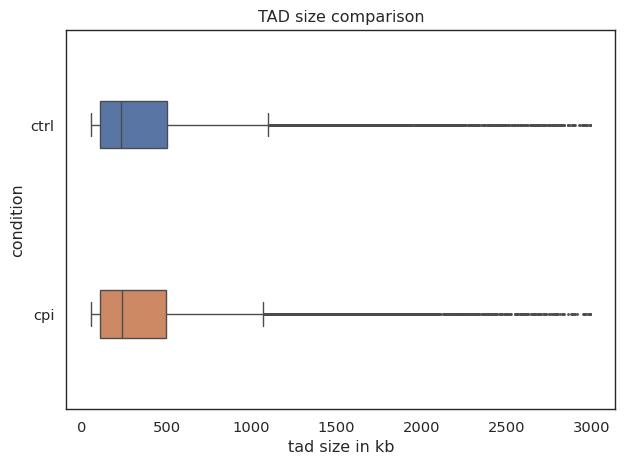

<Figure size 800x600 with 0 Axes>

In [12]:
sns.set_theme(
    rc={"axes.spines.top": False, "axes.spines.right": False}
)
sns.set_context('paper')
sns.set_palette("colorblind")
sns.set(style="white", context="paper", font_scale=1.2)
ax = sns.boxplot(
    data=combined,   # DataFrame as source
    width=0.25,
    fliersize=1,
    linewidth=1,
    showcaps=True,    x="tad_size_kb",     # Column for x-axis
    y="condition",     # Column for y-axis
    hue="condition"  # Column for color groups (optional)
)
ax.set(
    title="TAD size comparison",
    xlabel="tad size in kb",
    ylabel="condition"
)
ax.legend(
    loc="upper right",
    frameon=False
)
plt.tight_layout()
plt.figure(figsize=(8, 6))
plt.show()

/tmp/ipykernel_674837/898451861.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


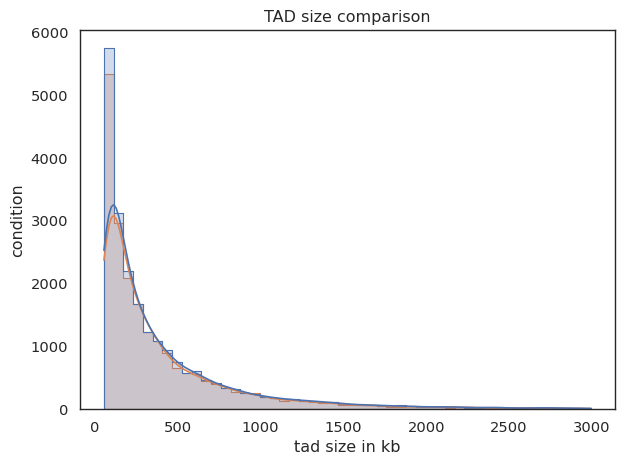

<Figure size 800x600 with 0 Axes>

In [13]:
sns.set_theme(
    rc={"axes.spines.top": False, "axes.spines.right": False}
)
sns.set_context('paper')
sns.set_palette("colorblind")
sns.set(style="white", context="paper", font_scale=1.2)
ax=sns.histplot(data=combined, x="tad_size_kb", hue="condition", bins=50, kde=True, element="step")
ax.set(
    title="TAD size comparison",
    xlabel="tad size in kb",
    ylabel="condition"
)
ax.legend(
    loc="upper right",
    frameon=False
)
plt.tight_layout()
plt.figure(figsize=(8, 6))
plt.show()

NameError: name 'ctrl_median' is not defined

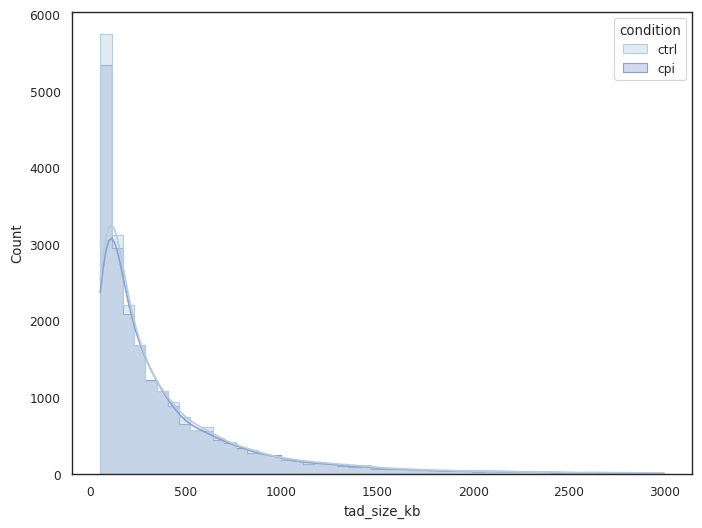

In [14]:
# Set styles
sns.set_theme(rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context('paper')
sns.set_style("white")
palette = {
    "ctrl": "#b3cde3",   # blue
    "cpi": "#8da0cb"     # vermillion/orange
}
sns.set_palette("colorblind")

# Initialize figure
plt.figure(figsize=(8, 6))

# Plot histogram
ax = sns.histplot(
    data=combined,
    x="tad_size_kb",
    hue="condition",
    bins=50,
    kde=True,
    element="step",
    alpha=0.4,
    palette=palette
)

# Add vertical lines for medians
ax.axvline(ctrl_median, color="green", linestyle="--", label="CTRL median")
ax.axvline(cpi_median, color="red", linestyle="--", label="CPI median")

# Log x-axis
ax.set_xscale("log")

# Set labels
ax.set(
    title="TAD size distribution (log scale)",
    xlabel="TAD size (kb, log scale)",
    ylabel="Count"
)

# Fix legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Condition", loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2155448/1530111067.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


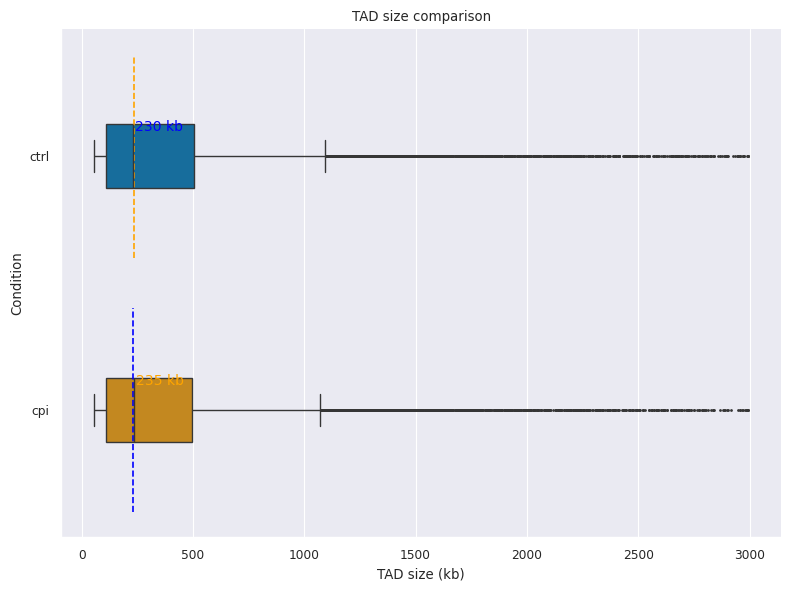

In [ ]:
# Set theme
sns.set_theme(rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context('paper')
sns.set_palette("colorblind")

# Create figure
plt.figure(figsize=(8, 6))

# Boxplot
ax = sns.boxplot(
    data=combined,
    width=0.25,
    fliersize=1,
    linewidth=1,
    showcaps=True,
    x="tad_size_kb",
    y="condition",
    hue="condition"
)

# Title and labels
ax.set(
    title="TAD size comparison",
    xlabel="TAD size (kb)",
    ylabel="Condition"
)

# Legend
ax.legend(
    loc="upper right",
    frameon=False
)

# Median lines + text (assuming 'ctrl' is at y=0 and 'cpi' at y=1)
ax.axvline(x=ctrl_median, color='blue', linestyle='--', ymin=0.05, ymax=0.45)
ax.axvline(x=cpi_median, color='orange', linestyle='--', ymin=0.55, ymax=0.95)


ax.text(ctrl_median + 10, -0.1, f"{ctrl_median:.0f} kb", color='blue', fontsize=10)
ax.text(cpi_median + 10,  0.9, f"{cpi_median:.0f} kb", color='orange', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
ctrl_median = ctrl_robustad["tad_size_kb"].median()
cpi_median = cpi_robustad["tad_size_kb"].median()
print(f"CTRL median TAD size: {ctrl_median:.1f} kb")
print(f"EED median TAD size: {cpi_median:.1f} kb")

CTRL median TAD size: 230.0 kb
EED median TAD size: 235.0 kb


---

In [ ]:
ctrl_mean = ctrl_robustad["tad_size_kb"].mean()
cpi_mean = cpi_robustad["tad_size_kb"].mean()
print(f"CTRL mean TAD size: {ctrl_mean:.1f} kb")
print(f"CPI mean TAD size: {cpi_mean:.1f} kb")

CTRL mean TAD size: 396.6 kb
CPI mean TAD size: 391.0 kb


/tmp/ipykernel_2155448/2980324159.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", frameon=False)


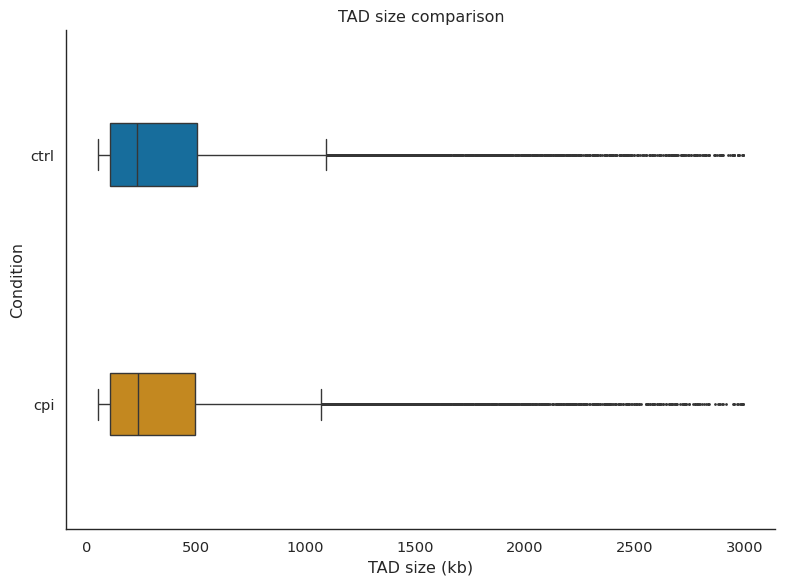

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply styles in the exact same order
sns.set_theme(rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context('paper')
sns.set_palette("colorblind")
sns.set(style="white", context="paper", font_scale=1.2)

# Create figure BEFORE plotting
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    data=combined,
    x="tad_size_kb",     # numeric variable
    y="condition",       # grouping variable
    hue="condition",     # color grouping
    width=0.25,
    fliersize=1,
    linewidth=1,
    showcaps=True
)

ax.set(
    title="TAD size comparison",
    xlabel="tad size in kb",
    ylabel="condition"
)
ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()
